In [2]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 171.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 184.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 202.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.1 MB/s eta 0:00:00


In [25]:
import pandas as pd
import numpy as np
import os
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from scipy.ndimage import uniform_filter

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path = '/content/drive/MyDrive/mvtec_anomaly_detection'
print(os.listdir(path))

['license.txt', 'readme.txt', '.DS_Store', 'bottle', 'screw', 'toothbrush', 'cable', 'grid', 'leather', 'carpet', 'hazelnut', 'tile', 'zipper', 'metal_nut', 'capsule', 'pill', 'transistor', 'wood']


In [6]:
for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"Folder: {item}")

Folder: bottle
Folder: screw
Folder: toothbrush
Folder: cable
Folder: grid
Folder: leather
Folder: carpet
Folder: hazelnut
Folder: tile
Folder: zipper
Folder: metal_nut
Folder: capsule
Folder: pill
Folder: transistor
Folder: wood


### For this dataset, since we are only looking at industrial parts, we will not be considering toothbrush, grid, leather, carpet, hazelnut, and tile

# Bottle

## Training

In [7]:
bottle_path = os.path.join(path, 'bottle')
bottle_train_path = os.path.join(bottle_path, 'train/good')
bottle_images_train = [f for f in os.listdir(bottle_train_path) if f.endswith('.png')]

if bottle_images_train:
    for i in range(0,5):
        image_filename = bottle_images_train[i]
        full_image_path = os.path.join(bottle_train_path, image_filename)
        try:
            img = Image.open(full_image_path)
            print(f"Successfully opened: {image_filename}")
            # Display the image (optional, works in Colab output)
            display(img)
        except FileNotFoundError:
            print(f"Error: Image file not found at {full_image_path}")
        except Exception as e:
            print(f"An error occurred while opening the image: {e}")
else:
    print("No images found in bottle_images_train to open.")

print(f"Contents of 'bottle/train' directory: {os.listdir(bottle_train_path)}")
print(f"Number of image files in 'bottle/train/good': {len(bottle_images_train)}")



Output hidden; open in https://colab.research.google.com to view.

### Define the Encoder

In [8]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3

def load_and_preprocess_image(image_path):
  img = Image.open(image_path).convert('RGB')
  img = img.resize((IMG_WIDTH, IMG_HEIGHT))
  img = np.array(img)
  img = img / 255.0 # Normalize to [0,1]
  return img

bottle_images_training_set = []
for img_filename in bottle_images_train:
  full_path = os.path.join(bottle_train_path, img_filename)
  bottle_images_training_set.append(load_and_preprocess_image(full_path))

X_train = np.array(bottle_images_training_set)
print(f"shape of training data: {X_train.shape}")



shape of training data: (209, 128, 128, 3)


In [9]:
LATENT_DIM = 32

def build_encoder(input_shape):
    encoder_input = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)    # 128 -> 64

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)    # 64 -> 32

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)    # 32 -> 16

    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)    # 16 -> 8

    # 8 x 8 x 256 = 16384 features
    x = layers.Flatten()(x)
    latent = layers.Dense(LATENT_DIM, activation='relu', name="latent")(x)

    encoder = models.Model(encoder_input, latent, name="encoder")
    return encoder

encoder = build_encoder((IMG_HEIGHT, IMG_WIDTH, CHANNELS))
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │       524,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 912,736 (3.48 MB)

 Trainable params: 912,736 (3.48 MB)

 Non-trainable params: 0 (0.00 B)

### Define the Decoder

In [10]:
def build_decoder(latent_dim, img_height=IMG_HEIGHT, img_width=IMG_WIDTH, channels=CHANNELS):
    decoder_input = layers.Input(shape=(latent_dim,))

    x = layers.Dense(8 * 8 * 256, activation='relu')(decoder_input)
    x = layers.Reshape((8, 8, 256))(x)

    x = layers.Conv2DTranspose(256, (3, 3), strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(128, (3, 3), strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(64,  (3, 3), strides=2, padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(32,  (3, 3), strides=2, padding='same', activation='relu')(x)

    decoded = layers.Conv2D(channels, (3, 3), padding='same', activation='sigmoid')(x)
    return models.Model(decoder_input, decoded, name="decoder")


decoder = build_decoder(latent_dim=LATENT_DIM)
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16384)          │       540,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,518,915 (5.79 MB)

 Trainable params: 1,518,915 (5.79 MB)

 Non-trainable params: 0 (0.00 B)

### Combine encoder and decoder to make autoencoder

In [11]:
# Custom loss function

import tensorflow as tf

def combined_ssim_mse_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.math.squared_difference(y_true, y_pred))
    ssim = tf.image.ssim(y_true, y_pred, max_val=1.0)
    ssim_loss = 1.0 - tf.reduce_mean(ssim)
    return 0.5 * mse + 0.5 * ssim_loss

In [12]:
def reconstruction_error(y_true, y_pred, kernel_size=3):
    err_maps = np.mean((y_true - y_pred)**2, axis=-1)
    scores = []
    for emap in err_maps:
        local_err = uniform_filter(emap, size=kernel_size, mode='reflect')
        scores.append(local_err.max())
    return np.array(scores)

In [13]:
autoencoder_input = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS))
encoded_output = encoder(autoencoder_input)
decoded_output = decoder(encoded_output)

autoencoder_bottle = models.Model(autoencoder_input, decoded_output, name="autoencoder")
autoencoder_bottle.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       912,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 128, 128, 3)    │     1,518,915 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,431,651 (9.28 MB)

 Trainable params: 2,431,651 (9.28 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
autoencoder_bottle.compile(optimizer='adam', loss=combined_ssim_mse_loss)

# Train the model
from sklearn.model_selection import train_test_split

# split good images into train (for AE) and validation (for threshold)
X_train_ae, X_val_good = train_test_split(
    X_train, test_size=0.2, random_state=42
)

history = autoencoder_bottle.fit(
    X_train_ae, X_train_ae,
    epochs=20,
    batch_size=32,
    shuffle=True,
    validation_data=(X_val_good, X_val_good)
)

print("Autoencoder training complete.")

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - loss: 0.3898 - val_loss: 0.3895
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.3893 - val_loss: 0.3871
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.3796 - val_loss: 0.3356
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.3224 - val_loss: 0.2715
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.2593 - val_loss: 0.2072
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.1887 - val_loss: 0.1302
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.1175 - val_loss: 0.0852
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0853 - val_loss: 0.0784
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0778 - val_loss: 0.0746
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0766 - val_loss: 0.0728
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0743 - val_loss: 0.0709
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.0724 - val_loss:

## Testing

In [15]:
# Use only the autoencoder training subset for "train errors"
X_train_reconstructed = autoencoder_bottle.predict(X_train_ae, batch_size=32)
reconstruction_errors_train = reconstruction_error(X_train_ae, X_train_reconstructed)
print(f"Shape of training reconstruction errors: {reconstruction_errors_train.shape}")

# Also compute errors on the held-out good validation set, for thresholding
X_val_reconstructed = autoencoder_bottle.predict(X_val_good, batch_size=32)
reconstruction_errors_val = reconstruction_error(X_val_good, X_val_reconstructed)
print(f"Shape of validation reconstruction errors: {reconstruction_errors_val.shape}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Shape of training reconstruction errors: (167,)
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Shape of validation reconstruction errors: (42,)


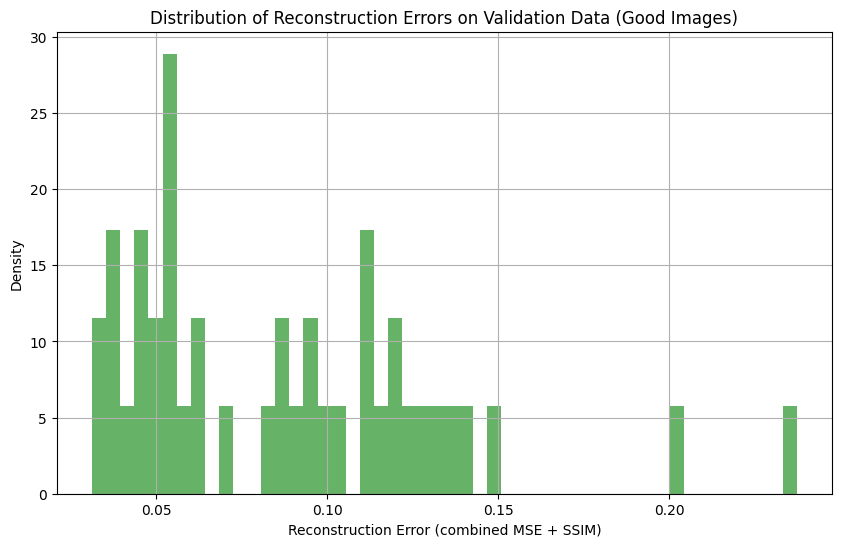

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(
    reconstruction_errors_val,   # <- use validation errors
    bins=50,
    density=True,
    alpha=0.6,
    color='g'
)
plt.title('Distribution of Reconstruction Errors on Validation Data (Good Images)')
plt.xlabel('Reconstruction Error (combined MSE + SSIM)')
plt.ylabel('Density')
plt.grid(True)
plt.show()


In [17]:
bottle_test_path = os.path.join(bottle_path, 'test')
bottle_images_test = []
y_test = []          # 0 = good, 1 = defective

test_subfolders = [f for f in os.listdir(bottle_test_path)
                   if os.path.isdir(os.path.join(bottle_test_path, f))]

for subfolder in test_subfolders:
    subfolder_path = os.path.join(bottle_test_path, subfolder)
    img_files_in_subfolder = [f for f in os.listdir(subfolder_path)
                              if f.lower().endswith('.png')]

    # Ground-truth label: good = 0, everything else = 1
    label = 0 if subfolder == 'good' else 1

    for img_filename in img_files_in_subfolder:
        full_path = os.path.join(subfolder_path, img_filename)
        bottle_images_test.append(load_and_preprocess_image(full_path))
        y_test.append(label)

X_test_bottle = np.array(bottle_images_test)
y_test = np.array(y_test)

print(f"Shape of testing data: {X_test_bottle.shape}")
print(f"Shape of testing labels: {y_test.shape}")

Shape of testing data: (83, 128, 128, 3)
Shape of testing labels: (83,)


In [18]:
X_test_bottle_reconstructed = autoencoder_bottle.predict(X_test_bottle, batch_size=32)
print(f"Shape of reconstructed test data: {X_test_bottle_reconstructed.shape}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Shape of reconstructed test data: (83, 128, 128, 3)


In [19]:
reconstruction_errors_test = reconstruction_error(X_test_bottle, X_test_bottle_reconstructed)
print(f"Shape of test reconstruction errors: {reconstruction_errors_test.shape}")

Shape of test reconstruction errors: (83,)


In [20]:
# choose threshold based on held-out good validation set
threshold = np.percentile(reconstruction_errors_val, 99)  # e.g., 99th percentile of GOOD images
print(f"Anomaly threshold (99th percentile of validation reconstruction errors): {threshold:.4f}")

Anomaly threshold (99th percentile of validation reconstruction errors): 0.2221


In [21]:
predictions = (reconstruction_errors_test > threshold).astype(int)
def_count = np.sum(predictions) # Count of defective (anomaly) images
good_count = len(predictions) - def_count # Count of good images

print(f"Number of defective images in test set: {def_count}")
print(f"Number of good images in test set: {good_count}")

Number of defective images in test set: 37
Number of good images in test set: 46


In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, predictions)
print(f"Overall test accuracy: {acc:.4f}")

cm = confusion_matrix(y_test, predictions)
print("Confusion matrix (rows = true, cols = pred):")
print(cm)

print("\nClassification report:")
print(classification_report(y_test, predictions, target_names=["good", "defective"]))

Overall test accuracy: 0.6867
Confusion matrix (rows = true, cols = pred):
[[20  0]
 [26 37]]

Classification report:
              precision    recall  f1-score   support

        good       0.43      1.00      0.61        20
   defective       1.00      0.59      0.74        63

    accuracy                           0.69        83
   macro avg       0.72      0.79      0.67        83
weighted avg       0.86      0.69      0.71        83



In [23]:
good_indices = np.where(predictions == 0)[0]
defective_indices = np.where(predictions == 1)[0]

# Select a few examples from each category
num_examples_per_category = 3
selected_good_indices = np.random.choice(good_indices, min(len(good_indices), num_examples_per_category), replace=False)
selected_defective_indices = np.random.choice(defective_indices, min(len(defective_indices), num_examples_per_category), replace=False)

# Combine and shuffle indices for display
example_indices = np.concatenate((selected_good_indices, selected_defective_indices))
np.random.shuffle(example_indices)

print(f"Selected good image indices: {selected_good_indices}")
print(f"Selected defective image indices: {selected_defective_indices}")

Selected good image indices: [54 28  7]
Selected defective image indices: [65 44 50]


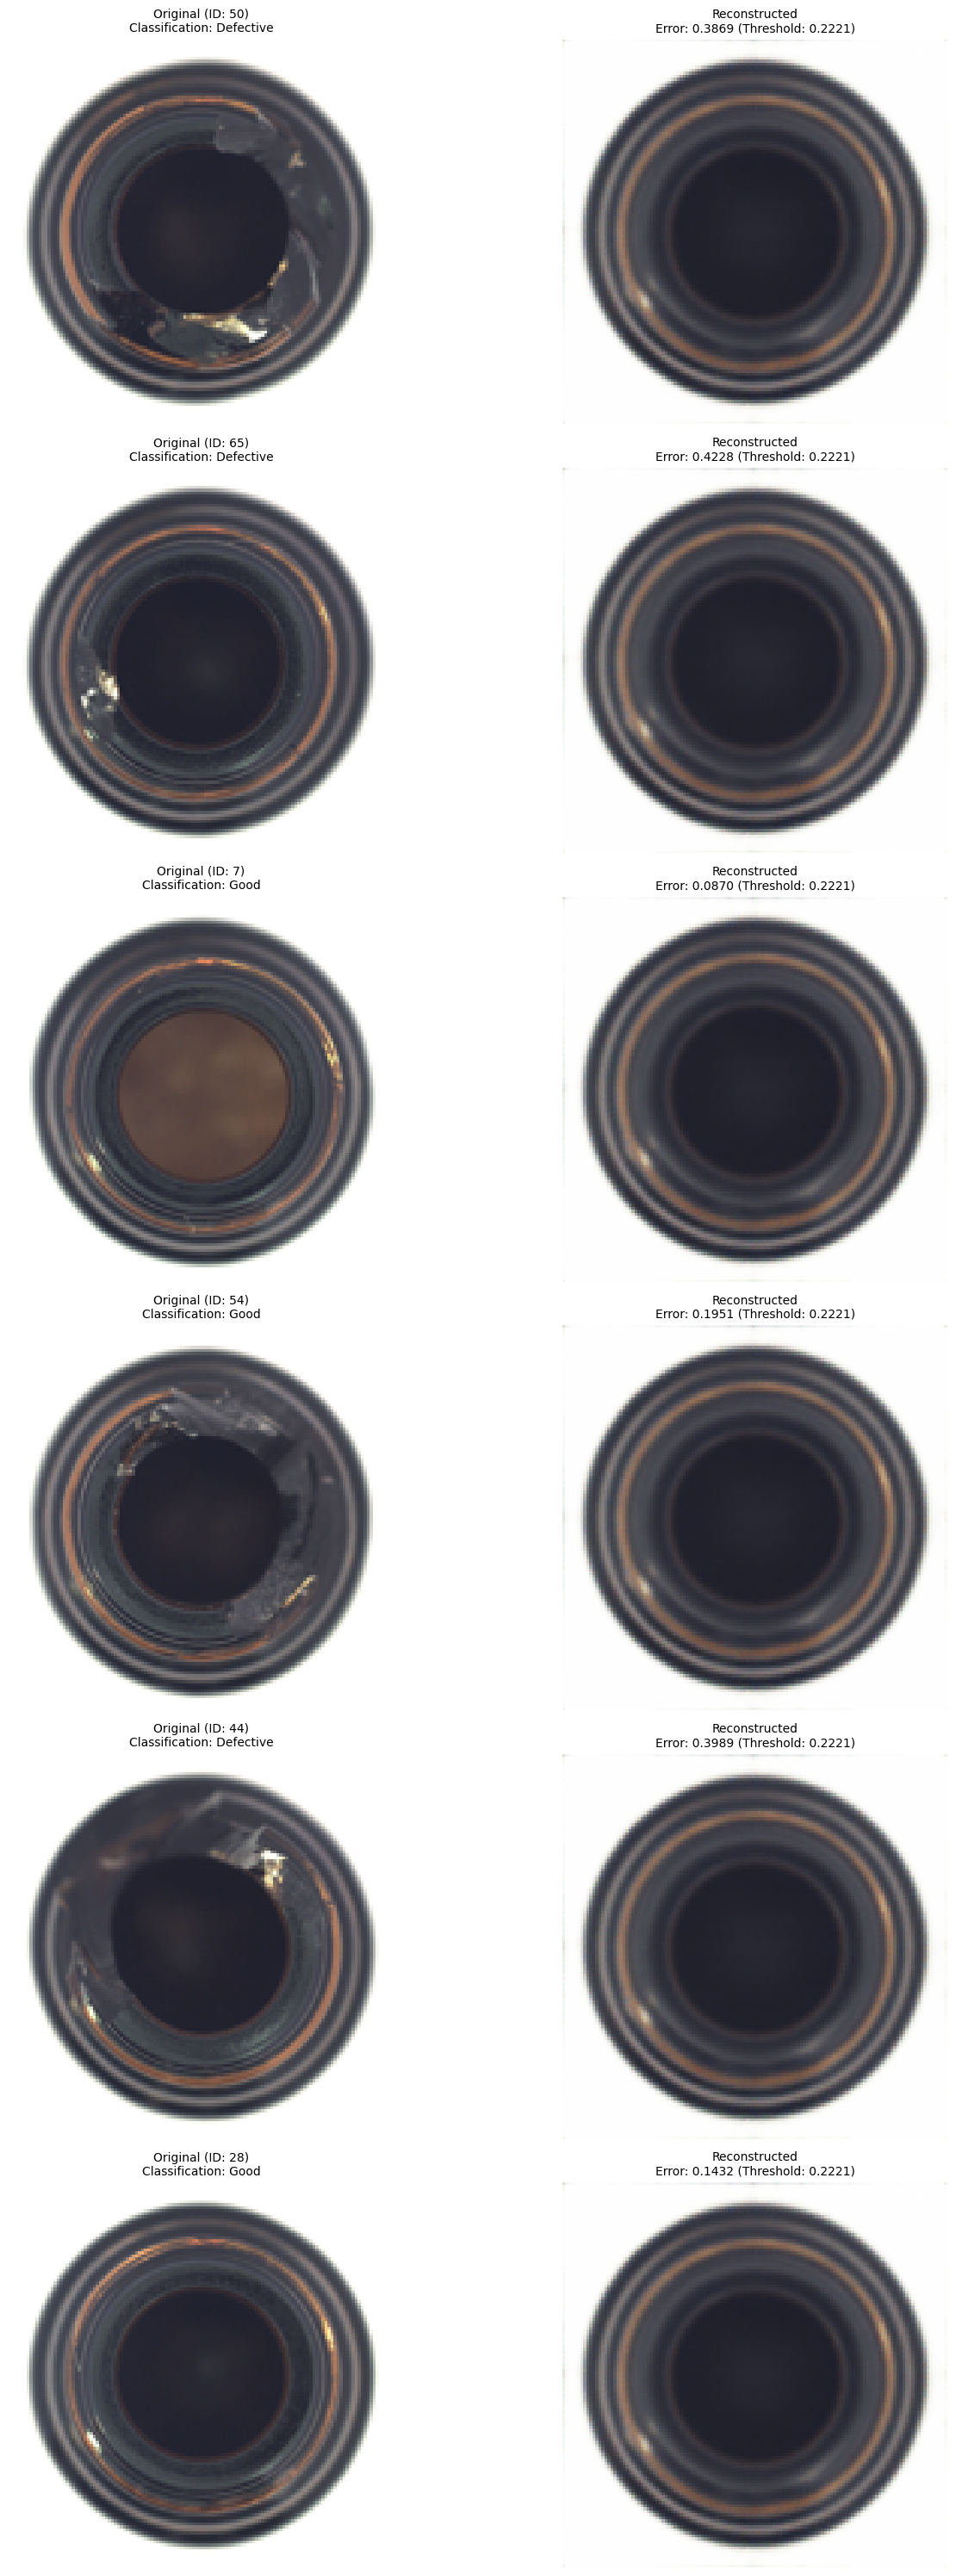

In [24]:
plt.figure(figsize=(15, 5 * len(example_indices)))

for i, idx in enumerate(example_indices):
    original_image = X_test_bottle[idx]
    reconstructed_image = X_test_bottle_reconstructed[idx]
    error = reconstruction_errors_test[idx]
    classification = "Defective" if predictions[idx] == 1 else "Good"

    # Plot original image
    plt.subplot(len(example_indices), 2, 2 * i + 1)
    plt.imshow(original_image)
    plt.title(f"Original (ID: {idx})\nClassification: {classification}", fontsize=10)
    plt.axis('off')

    # Plot reconstructed image
    plt.subplot(len(example_indices), 2, 2 * i + 2)
    plt.imshow(reconstructed_image)
    plt.title(f"Reconstructed\nError: {error:.4f} (Threshold: {threshold:.4f})", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()
